In [1]:
import operator
from dataclasses import dataclass
from pprint import pprint
from typing import Annotated, List, Literal, TypedDict

from IPython.display import Image, display
from langchain.agents import create_agent
from langchain.agents.middleware import HumanInTheLoopMiddleware
from langchain_community.utilities import SQLDatabase
from langchain_core.tools import tool
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import END, START, StateGraph
from langgraph.runtime import get_runtime
from langgraph.types import Command, interrupt

DB = SQLDatabase.from_uri("sqlite:///../../data/contos.sqlite")


## Primero grafo

In [2]:
class State(TypedDict):
    nlist: List[str]

def node_a(state: State) -> State:
    print(f'node a is receiving {state['nlist']}')
    note = 'Hello World! (from node a)'
    return State(nlist=[note])

builder = StateGraph(State)
builder.add_node('a', node_a)
builder.add_edge(START, 'a')
builder.add_edge('a', END)
graph = builder.compile()


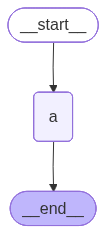

In [3]:
display(Image(graph.get_graph().draw_mermaid_png()))
# print(graph.get_graph().draw_mermaid())  # Uncomment to print the graph in text format

In [4]:
initial_state = State(
    nlist=['oioioi']
    )

graph.invoke(initial_state)

node a is receiving ['oioioi']


{'nlist': ['Hello World! (from node a)']}

## Segundo grafo

In [5]:
from IPython.display import Image, display
import operator
from typing import Annotated, List, Literal, TypedDict
from langgraph.graph import END, START, StateGraph
from langgraph.types import Command, interrupt


In [6]:
class State(TypedDict):
    nlist: Annotated[List[str], operator.add]

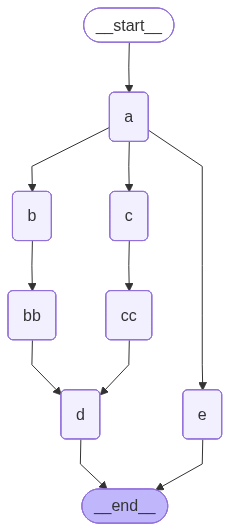

In [7]:
def node_a(state: State) -> State:
    print(f"Adding 'A' to {state['nlist']}")
    return State(nlist= ['A'])

def node_b(state: State) -> State:
    print(f"Adding 'B' to {state['nlist']}")
    return State(nlist= ['B'])

def node_c(state: State) -> State:
    print(f"Adding 'C' to {state['nlist']}")
    return State(nlist= ['C'])

def node_bb(state: State) -> State:
    print(f"Adding 'BB' to {state['nlist']}")
    return State(nlist= ['BB'])

def node_cc(state: State) -> State:
    print(f"Adding 'CC' to {state['nlist']}")
    return State(nlist= ['CC'])

def node_d(state: State) -> State:
    print(f"Adding 'D' to {state['nlist']}")
    return State(nlist= ['D'])

def node_e(state: State) -> State:
    print(f"Adding 'E' to {state['nlist']}")
    return State(nlist= ['E'])

builder = StateGraph(State)

# Add nodes
builder.add_node('a', node_a)
builder.add_node('b', node_b)
builder.add_node('bb', node_bb)
builder.add_node('c', node_c)
builder.add_node('cc', node_cc)
builder.add_node('e', node_e)
builder.add_node('d', node_d)

# Add edges
builder.add_edge(START, 'a')
builder.add_edge('a', 'b')
builder.add_edge('a', 'c')
builder.add_edge('a', 'e')
builder.add_edge('b', 'bb')
builder.add_edge('c', 'cc')
builder.add_edge('bb', 'd')
builder.add_edge('cc', 'd')
builder.add_edge('d', END)
builder.add_edge('e', END)

# Compile and Display
graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))


In [8]:
initial_state = State(
    nlist=['Initial String:']
)

graph.invoke(initial_state)

Adding 'A' to ['Initial String:']
Adding 'B' to ['Initial String:', 'A']
Adding 'C' to ['Initial String:', 'A']
Adding 'E' to ['Initial String:', 'A']
Adding 'BB' to ['Initial String:', 'A', 'B', 'C', 'E']
Adding 'CC' to ['Initial String:', 'A', 'B', 'C', 'E']
Adding 'D' to ['Initial String:', 'A', 'B', 'C', 'E', 'BB', 'CC']


{'nlist': ['Initial String:', 'A', 'B', 'C', 'E', 'BB', 'CC', 'D']}

## Terceiro Grafo

In [9]:
from IPython.display import Image, display
import operator
from typing import Annotated, List, Literal, TypedDict
from langgraph.graph import END, START, StateGraph
from langgraph.types import Command, interrupt

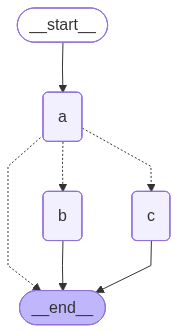

In [10]:
class State(TypedDict):
    nlist: Annotated[List[str], operator.add]

def node_a(state: State) -> State:
    return

def node_b(state: State) -> State:
    return State(nlist= ['B'])

def node_c(state: State) -> State:
    return State(nlist= ['C'])

# Condição é uma função
def conditional_edge(state: State) -> Literal['b', 'c', END]:
    select = state['nlist'][-1]
    if select == 'b':
        return 'b'
    elif select == 'c':
        return 'c'
    elif select == 'q':
        return END
    else:
        return END


builder = StateGraph(State)

# Add nodes
builder.add_node('a', node_a)
builder.add_node('b', node_b)
builder.add_node('c', node_c)

# Add edges
builder.add_edge(START, 'a')
builder.add_edge('b', END)
builder.add_edge('c', END)
builder.add_conditional_edges('a', conditional_edge)

# Compile and Display
graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [11]:
user = input('b, c or q to quit: ')

initial_state = State(
    nlist=[user]
)

graph.invoke(initial_state)

{'nlist': ['q']}

### ou...

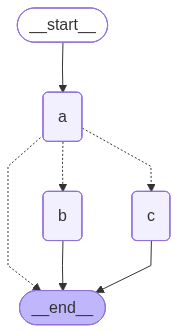

In [12]:
def node_a(state: State) -> Command[Literal['b', 'c', END]]:
    select = state['nlist'][-1]
    if select == 'b':
        next_node = 'b'
    elif select == 'c':
        next_node = 'c'
    elif select == 'q':
        next_node = END
    else:
        next_node = END

    return Command(
        update = State(nlist = [select]),
        goto = [next_node]
    )

def node_b(state: State) -> State:
    return State(nlist= ['B'])

def node_c(state: State) -> State:
    return State(nlist= ['C'])


builder = StateGraph(State)

# Add nodes
builder.add_node('a', node_a)
builder.add_node('b', node_b)
builder.add_node('c', node_c)

# Add edges
builder.add_edge(START, 'a')
builder.add_edge('b', END)
builder.add_edge('c', END)

# Compile and Display
graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [13]:
user = input('b, c or q to quit: ')

initial_state = State(
    nlist=[user]
)

graph.invoke(initial_state)

{'nlist': ['q', 'q']}

In [15]:
config = {'configurable': {'thread_id': '1'}}
while True:
    user = input('b, c or q to quit: ')
    input_state = State(nlist=[user])
    result = graph.invoke(input_state, config=config)
    print(   result   )
    if result['nlist'][-1] == 'q':
        print('Exiting...')
        break

{'nlist': ['q', 'q']}
Exiting...


## Quarto grafo - MEMÓRIA

In [16]:
from langgraph.checkpoint.memory import InMemorySaver
memory = InMemorySaver()
config = {'configurable': {'thread_id': '1'}}

In [17]:
graph = builder.compile(checkpointer = memory)

In [18]:
while True:
    user = input('b, c or q to quit: ')
    input_state = State(nlist=[user])
    result = graph.invoke(input_state, config=config)
    print(   result   )
    if result['nlist'][-1] == 'q':
        print('Exiting...')
        break

{'nlist': ['c', 'c', 'C']}
{'nlist': ['c', 'c', 'C', 'b', 'b', 'B']}
{'nlist': ['c', 'c', 'C', 'b', 'b', 'B', 'q', 'q']}
Exiting...


## Human in the loop

In [ ]:
def node_a(state: State) -> Command[Literal['b', 'c', END]]:
    select = state['nlist'][-1]
    if select == 'b':
        next_node = 'b'
    elif select == 'c':
        next_node = 'c'
    elif select == 'q':
        next_node = END
    else:
        admin = interrupt(f'Unexpected input: {select}')
        print(admin)
        if admin == 'continue':
            next_node = 'b'
        else:
            next_node = END
            select = 'q'
            

    return Command(
        update = State(nlist = [select]),
        goto = [next_node]
    )

def node_b(state: State) -> State:
    return State(nlist= ['B'])

def node_c(state: State) -> State:
    return State(nlist= ['C'])
    

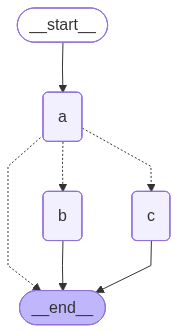

In [22]:
builder = StateGraph(State)

# Add nodes
builder.add_node('a', node_a)
builder.add_node('b', node_b)
builder.add_node('c', node_c)

# Add edges
builder.add_edge(START, 'a')
builder.add_edge('b', END)
builder.add_edge('c', END)

# Compile and Display
graph = builder.compile(checkpointer = memory)

display(Image(graph.get_graph().draw_mermaid_png()))

In [25]:
config = {'configurable': {'thread_id': '3'}}
while True:
    user = input('b, c or q to quit: ')
    input_state = State(nlist=[user])
    result = graph.invoke(input_state, config=config)

    if '__interrupt__' in result:
        print(f'Interrupt: {result}')
        msg = result['__interrupt__'][-1].value
        print(f'Message: {msg}')
        human = input(f'\n{msg}: ')

        human_response = Command(
            resume= human
        )

        result = graph.invoke(human_response, config=config)

    if result['nlist'][-1] == 'q':
        print('Exiting...')
        break

Interrupt: {'nlist': ['b', 'b', 'B', 'g', 'q', 'c', 'c', 'C', 'f'], '__interrupt__': [Interrupt(value='Unexpected input: f', id='836fcab51d7e49ac43182561f6dfda6b')]}
Message: Unexpected input: f

Exiting...
